In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/temp_co2_merged.csv")
df.head()

Matplotlib is building the font cache; this may take a moment.


,year,temp_anomaly,co2_ppm
0,1959,0.03,315.98
1,1960,-0.02,316.91
2,1961,0.06,317.64
3,1962,0.03,318.45
4,1963,0.05,318.99


In [3]:
df.describe()

,year,temp_anomaly,co2_ppm
count,67.000000,67.000000,67.000000
mean,1992.000000,0.399552,361.251045
std,19.485037,0.369436,32.899746
min,1959.000000,-0.200000,315.980000
25%,1975.500000,0.065000,331.580000
50%,1992.000000,0.330000,356.540000
75%,2008.500000,0.655000,386.735000
max,2025.000000,1.290000,427.350000


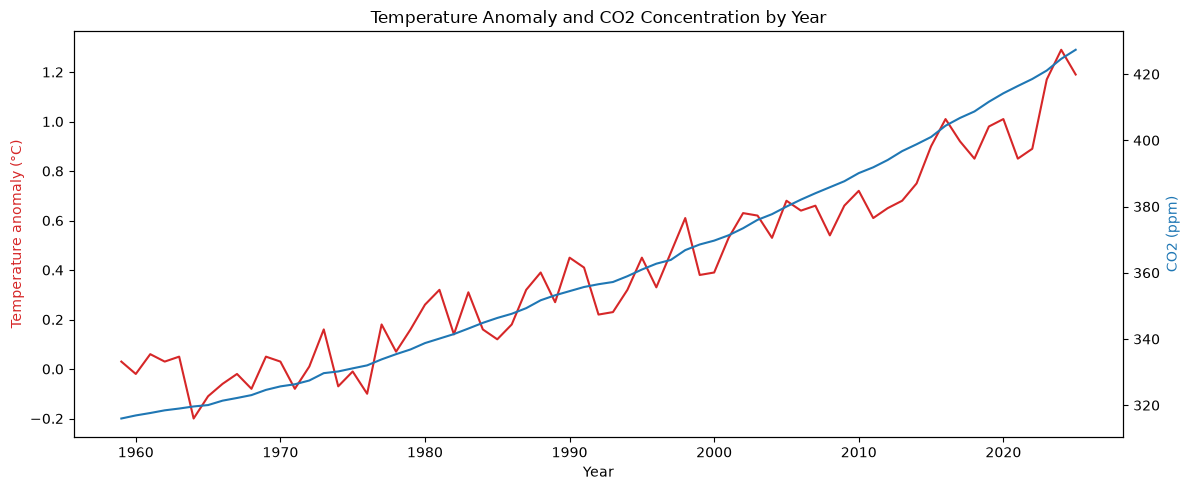

In [4]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df["year"], df["temp_anomaly"], color="tab:red", label="Temperature anomaly")
ax1.set_xlabel("Year")
ax1.set_ylabel("Temperature anomaly (°C)", color="tab:red")

ax2 = ax1.twinx()  # second Y-axis on the same plot
ax2.plot(df["year"], df["co2_ppm"], color="tab:blue", label="CO2 (ppm)")
ax2.set_ylabel("CO2 (ppm)", color="tab:blue")

plt.title("Temperature Anomaly and CO2 Concentration by Year")
fig.tight_layout()
plt.savefig("../data/raw/temp_co2_plot.png", dpi=150)
plt.show()


In [5]:
correlation=df["temp_anomaly"].corr(df["co2_ppm"])
print(f"Correlation: {correlation:.3f}")

Correlation: 0.967


In [6]:
train=df[df["year"] <=2010]
test=df[df["year"] >2010]

print(f"Train: {len(train)} rows ({train['year'].min()}-{train['year'].max()})")
print(f"Test: {len(test)} rows ({test['year'].min()}-{test['year'].max()})")


Train: 52 rows (1959-2010)
Test: 15 rows (2011-2025)


In [7]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

X_train=train[["year", "co2_ppm"]]
y_train=train["temp_anomaly"]
X_test=test[["year", "co2_ppm"]]
y_test=test["temp_anomaly"]

lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
print(f"Linear Regression — MAE: {mae_lr:.3f}, RMSE: {rmse_lr:.3f}")

Linear Regression — MAE: 0.110, RMSE: 0.133


In [8]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
print(f"Random Forest — MAE: {mae_rf:.3f}, RMSE: {rmse_rf:.3f}")

Random Forest — MAE: 0.247, RMSE: 0.302


In [9]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
gb.fit(X_train, y_train)
pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, pred_gb))
print(f"Gradient Boosting — MAE: {mae_gb:.3f}, RMSE: {rmse_gb:.3f}")

Gradient Boosting — MAE: 0.231, RMSE: 0.281


In [10]:
results = pd.DataFrame({
    "model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "MAE": [mae_lr, mae_rf, mae_gb],
    "RMSE": [rmse_lr, rmse_rf, rmse_gb],
})
print(results)

               model       MAE      RMSE
0  Linear Regression  0.110171  0.132913
1      Random Forest  0.247150  0.301697
2  Gradient Boosting  0.230916  0.281430


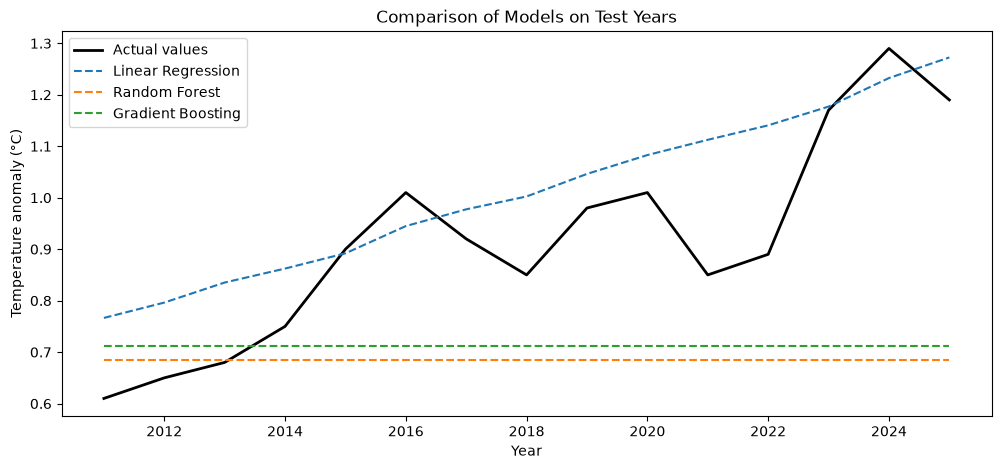

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(test["year"], y_test, label="Actual values", color="black", linewidth=2)
plt.plot(test["year"], pred_lr, label="Linear Regression", linestyle="--")
plt.plot(test["year"], pred_rf, label="Random Forest", linestyle="--")
plt.plot(test["year"], pred_gb, label="Gradient Boosting", linestyle="--")
plt.xlabel("Year")
plt.ylabel("Temperature anomaly (°C)")
plt.legend()
plt.title("Comparison of Models on Test Years")
plt.savefig("../data/raw/model_comparison.png", dpi=150)
plt.show()


In [ ]:
from sklearn.linear_model import LinearRegression

# CO2 trend over the last 15 years
recent = df[df["year"] >= df["year"].max() - 15]
co2_trend = LinearRegression().fit(recent[["year"]], recent["co2_ppm"])

# Create future years for the next 10 years
future_years = pd.DataFrame({"year": range(df["year"].max() + 1, df["year"].max() + 11)})
future_years["co2_ppm"] = co2_trend.predict(future_years[["year"]])

# Use the best-performing model
future_years["predicted_temp_anomaly"] = lr.predict(future_years[["year", "co2_ppm"]])

print(future_years)

   year     co2_ppm  predicted_temp_anomaly
0  2026  429.029250                1.292106
1  2027  431.515779                1.327305
2  2028  434.002309                1.362503
3  2029  436.488838                1.397702
4  2030  438.975368                1.432900
5  2031  441.461897                1.468099
6  2032  443.948426                1.503297
7  2033  446.434956                1.538496
8  2034  448.921485                1.573694
9  2035  451.408015                1.608893
